In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
ds=fetch_openml('mnist_784')
images = ds.data.to_numpy().reshape(-1,28,28)
labels = ds.target.astype(int)

In [5]:
print(images[0])
print(ds.data.shape)

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

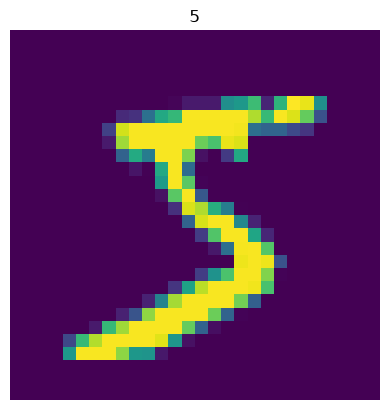

In [8]:
plt.imshow(images[0])
plt.axis("off")
plt.title(labels[0])
plt.show()

In [15]:
#with scaling
import time
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

X = images.reshape(len(images), -1)
newx =X/255.0
xtrain, xtest, ytrain, ytest=train_test_split(newx, labels, test_size=0.2, random_state=42) #extra param 

mlp=MLPClassifier(hidden_layer_sizes=(128,), max_iter=1000, random_state=42)  #training
start=time.time()
mlp.fit(xtrain,ytrain)
end=time.time()

trainP=mlp.predict(xtrain)  #predictions
testP=mlp.predict(xtest)

trainA=accuracy_score(trainP,ytrain)
testA=accuracy_score(testP,ytest)
print("Training Accuracy: ",trainA)
print("Testing Accuracy: ",testA)
print("Training Time: ",end-start)

Training Accuracy:  1.0
Testing Accuracy:  0.9785714285714285
Training Time:  194.64733719825745


In [13]:
print(newx.shape)
print(xtrain.shape)

(70000, 28, 28)
(56000, 28, 28)


In [16]:
import time
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

X = images.reshape(len(images), -1)
xtrain, xtest, ytrain, ytest=train_test_split(X, labels, test_size=0.2, random_state=42) #extra param 

mlp=MLPClassifier(hidden_layer_sizes=(128,), max_iter=1000, random_state=42)  #training
start=time.time()
mlp.fit(xtrain,ytrain)
end=time.time()

trainP=mlp.predict(xtrain)  #predictions
testP=mlp.predict(xtest)

trainA=accuracy_score(trainP,ytrain)
testA=accuracy_score(testP,ytest)
print("Training Accuracy: ",trainA)
print("Testing Accuracy: ",testA)
print("Training Time: ",end-start)

Training Accuracy:  0.9949285714285714
Testing Accuracy:  0.9668571428571429
Training Time:  439.769677400589


In [17]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(ytest, testP)

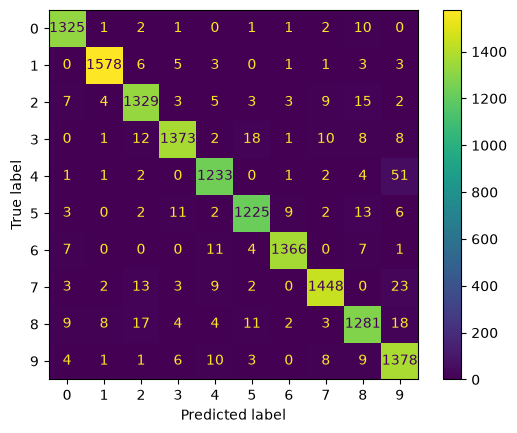

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(cm).plot()
plt.show()

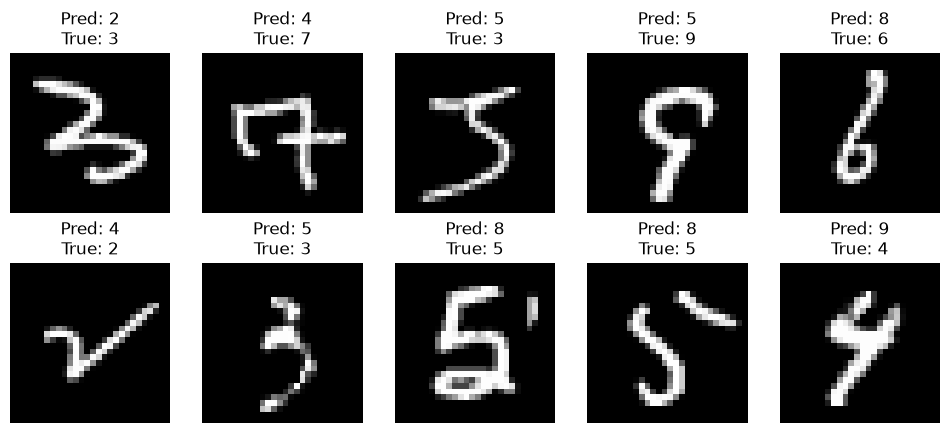

In [20]:
wr=testP!=ytest

wrong_images = xtest[wr]
wrong_predictions = testP[wr]
wrong_labels = ytest[wr]

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(wrong_images[i].reshape(28, 28), cmap="gray")
    plt.title(f"Pred: {wrong_predictions[i]}\nTrue: {wrong_labels.iloc[i]}")
    plt.axis("off")

plt.show()